# Ejemplo: casos adversarios con VGG16

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana04_adversarial_FD.ipynb)

Utilizando el conocimiento de Física Diferenciable, queremos realizar ataques adversarios a una red VGG16 entrenada. Queremos pensar cómo debemos modificar la imagen de entrada para que la red se confunda de clase! Esto lo podemos hacer si pensamos a la red VGG16 como un simulador, que depende de la imagen de entrada y cuyo objetivo es una determinada clase objetivo. 

Planteamos el problema de optimización como cuál es la modificación (perturbación) que debo hacer a la imagen de entrada, de manera tal de que la predicción sea la que yo quiera, es decir una clase objetivo seleccionada a priori (independientemente de que la imagen de entrada sea esa clase objetivo o no). 

Eso produce un ejemplo adversario: no entrenamos el modelo, sino que optimizamos la **imagen** para que engañe a la red.

## Preparación

Usamos un modelo VGG16 preentrenado de `torchvision`. Sus pesos permanecerán congelados durante todo el notebook porque el objetivo no es entrenar la red, sino encontrar una perturbacion a la imagen seleccionada tal que engañe a la red.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import models, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("dispositivo:", device)

with open("imagenet.json") as f:
    imagenet_labels = json.load(f)

try:
    weights = models.VGG16_Weights.DEFAULT
    model = models.vgg16(weights=weights)
except AttributeError:
    model = models.vgg16(pretrained=True)

model = model.to(device).eval()
# acá congelamos los pesos del modelo, ya que no los vamos a actualizar
for param in model.parameters():
    param.requires_grad = False

imagenet_mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
imagenet_std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

to_tensor = transforms.ToTensor()

dispositivo: cpu


## Cargar y mostrar la imagen

Usamos `PIL` para evitar la confusión entre BGR y RGB que suele aparecer con `cv2`.

In [2]:
import requests
from io import BytesIO
def load_image(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")
    return img

In [9]:
!unset proxy_https

In [ ]:
im = load_image("https://t1.gstatic.com/licensed-image?q=tbn:ANd9GcSQgHnpqrWBnv3Y7q-Q9sXdNxFAxXCvyaDg38Qs04T7rcLw-Bk8UJQngdqO_T2NGp1jwnHY-AaeJYms9cZndhE")
im = load_image("http://t1.gstatic.com/licensed-image?q=tbn:ANd9GcQ4acvCNG_ou7PKgWfo4gyBlind6CGzskM_1MwF00Hsq0Zu9QxFs0Wo1MoFqDwb7-olbTqj2aOvpTCl4nOTMww")
plt.imshow(im)

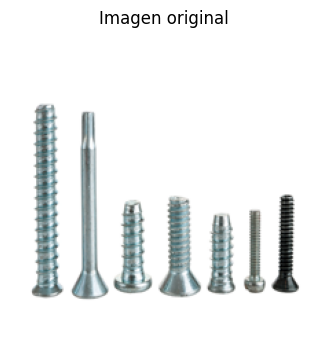

In [23]:
pil_image= im.convert("RGB").resize((224, 224))
image=to_tensor(pil_image).unsqueeze(0).to(device)
plt.figure(figsize=(4, 4))
plt.imshow(pil_image)
plt.axis("off")
plt.title("Imagen original")
plt.show()

## Funciones auxiliares

Estas funciones condensan el proceso completo.

- `normalize_batch`: adapta la imagen al formato que espera VGG16.
- `predict_topk`: devuelve las clases más probables.
- `targeted_attack_step`: realiza **un paso de optimización** sobre la imagen.

Ese último punto es donde aparece la analogía más clara con física diferenciable: la imagen actual actúa como estado de entrada, la red actúa como sistema diferenciable, la pérdida mide qué tan lejos estamos del objetivo y `backward()` propaga el gradiente hasta los píxeles.

In [24]:
def normalize_batch(batch):
    return (batch - imagenet_mean) / imagenet_std


def predict_topk(batch, k=5):
    with torch.no_grad():
        logits = model(normalize_batch(batch))
        probs = F.softmax(logits, dim=1)
        top_probs, top_indices = probs.topk(k, dim=1)

    rows = []
    for prob, idx in zip(top_probs[0].cpu().tolist(), top_indices[0].cpu().tolist()):
        rows.append((idx, imagenet_labels[str(idx)] if str(idx) in imagenet_labels else imagenet_labels[idx], prob))
    return rows


def show_predictions(batch, title, k=5):
    print(title)
    for idx, label, prob in predict_topk(batch, k=k):
        print(f"  clase {idx:4d}: {label:25s}  prob={100 * prob:6.2f}%")


def targeted_attack_step(current_image, target_index, step_size):
    attack_image = current_image.clone().detach().requires_grad_(True)
    logits = model(normalize_batch(attack_image))
    target = torch.tensor([target_index], device=device)
    loss = F.cross_entropy(logits, target)
    loss.backward()

    with torch.no_grad():
        updated_image = attack_image - step_size * attack_image.grad
        updated_image = updated_image.clamp(0.0, 1.0)

    return updated_image.detach(), loss.item(), attack_image.grad.detach()

## Inspeccionar la predicción original

Antes de atacar la imagen, observamos qué cree ver el modelo.

In [25]:
show_predictions(image, "Predicciones antes del ataque")

Predicciones antes del ataque
  clase  783: screw                      prob= 99.68%
  clase  677: nail                       prob=  0.32%
  clase  784: screwdriver                prob=  0.00%
  clase  506: coil                       prob=  0.00%
  clase  543: dumbbell                   prob=  0.00%


## Elegir una clase objetivo

Fijamos una clase manualmente como objetivo. 

En un ataque dirigido, la pregunta es: **¿cómo debo modificar la imagen para que el clasificador crea que pertenece a esta clase?**

In [26]:
target_index = 2
target_label = imagenet_labels[str(target_index)] if str(target_index) in imagenet_labels else imagenet_labels[target_index]
print("Clase objetivo:", target_index, target_label)

Clase objetivo: 2 great white shark


## Entender un solo paso de gradiente

Este es el núcleo conceptual del notebook.

Calculamos el gradiente de la pérdida con respecto a cada píxel. Ese gradiente responde a la pregunta:

**si cambio un poco este píxel, cómo cambia la pérdida de la clase objetivo?**

Esa es exactamente la lógica de los sistemas diferenciables: obtener sensibilidad de la salida con respecto a las entradas o parámetros.

In [27]:
one_step_image, one_step_loss, one_step_grad = targeted_attack_step(image, target_index, step_size=0.01)
print("Pérdida tras calcular un paso:", one_step_loss)
print("Forma del gradiente:", tuple(one_step_grad.shape))
print("Mínimo/máximo del gradiente:", one_step_grad.min().item(), one_step_grad.max().item())

Pérdida tras calcular un paso: 31.317428588867188
Forma del gradiente: (1, 3, 224, 224)
Mínimo/máximo del gradiente: -0.8111703395843506 1.074661135673523


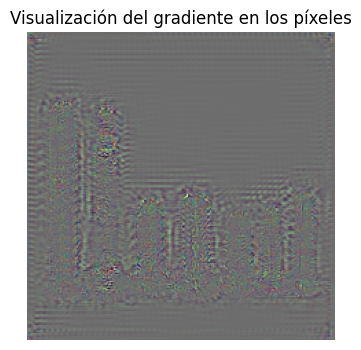

In [28]:
grad_vis = one_step_grad[0].detach().cpu().numpy()
grad_vis = np.transpose(grad_vis, (1, 2, 0))
grad_vis = grad_vis - grad_vis.min()
grad_vis = grad_vis / max(grad_vis.max(), 1e-8)

plt.figure(figsize=(4, 4))
plt.imshow(grad_vis)
plt.axis("off")
plt.title("Visualización del gradiente en los píxeles")
plt.show()

## Ejecutar el ataque completo

Ahora repetimos el paso de gradiente muchas veces.

En cada iteración:

1. pasamos la imagen actual por VGG16,
2. calculamos la pérdida para la clase objetivo,
3. hacemos backpropagation,
4. actualizamos los píxeles,
5. recortamos los valores al rango válido `[0, 1]`.

In [30]:
num_steps = 100
step_size = 0.01

attack_image = image.clone().detach()
loss_history = []
target_prob_history = []

for step in range(num_steps):
    attack_image, loss_value, _ = targeted_attack_step(attack_image, target_index, step_size)
    loss_history.append(loss_value)

    with torch.no_grad():
        probs = F.softmax(model(normalize_batch(attack_image)), dim=1)
        target_prob = probs[0, target_index].item()
        target_prob_history.append(target_prob)

    print(f"paso {step + 1:02d}: pérdida={loss_value:.4f}, prob_objetivo={100 * target_prob:.2f}%")

paso 01: pérdida=31.3174, prob_objetivo=0.00%
paso 02: pérdida=27.9523, prob_objetivo=0.00%
paso 03: pérdida=22.9955, prob_objetivo=0.00%
paso 04: pérdida=17.4814, prob_objetivo=0.00%
paso 05: pérdida=13.6885, prob_objetivo=0.00%
paso 06: pérdida=11.0174, prob_objetivo=0.01%
paso 07: pérdida=9.1128, prob_objetivo=0.03%
paso 08: pérdida=7.9584, prob_objetivo=0.07%
paso 09: pérdida=7.3109, prob_objetivo=0.11%
paso 10: pérdida=6.7813, prob_objetivo=0.18%
paso 11: pérdida=6.3123, prob_objetivo=0.35%
paso 12: pérdida=5.6564, prob_objetivo=0.79%
paso 13: pérdida=4.8388, prob_objetivo=1.72%
paso 14: pérdida=4.0629, prob_objetivo=3.16%
paso 15: pérdida=3.4538, prob_objetivo=7.05%
paso 16: pérdida=2.6526, prob_objetivo=13.56%
paso 17: pérdida=1.9984, prob_objetivo=25.63%
paso 18: pérdida=1.3616, prob_objetivo=37.76%
paso 19: pérdida=0.9739, prob_objetivo=49.23%
paso 20: pérdida=0.7086, prob_objetivo=57.22%
paso 21: pérdida=0.5582, prob_objetivo=62.37%
paso 22: pérdida=0.4721, prob_objetivo=65.4

## 9. Comparar predicciones antes y después

In [31]:
show_predictions(image, "Predicciones antes del ataque")
print()
show_predictions(attack_image, "Predicciones después del ataque")

Predicciones antes del ataque
  clase  783: screw                      prob= 99.68%
  clase  677: nail                       prob=  0.32%
  clase  784: screwdriver                prob=  0.00%
  clase  506: coil                       prob=  0.00%
  clase  543: dumbbell                   prob=  0.00%

Predicciones después del ataque
  clase    2: great white shark          prob= 95.73%
  clase    3: tiger shark                prob=  1.25%
  clase    4: hammerhead shark           prob=  0.74%
  clase  833: submarine                  prob=  0.61%
  clase  394: sturgeon                   prob=  0.45%


La perturbación suele ser pequeña en magnitud, pero puede cambiar mucho la salida del modelo.

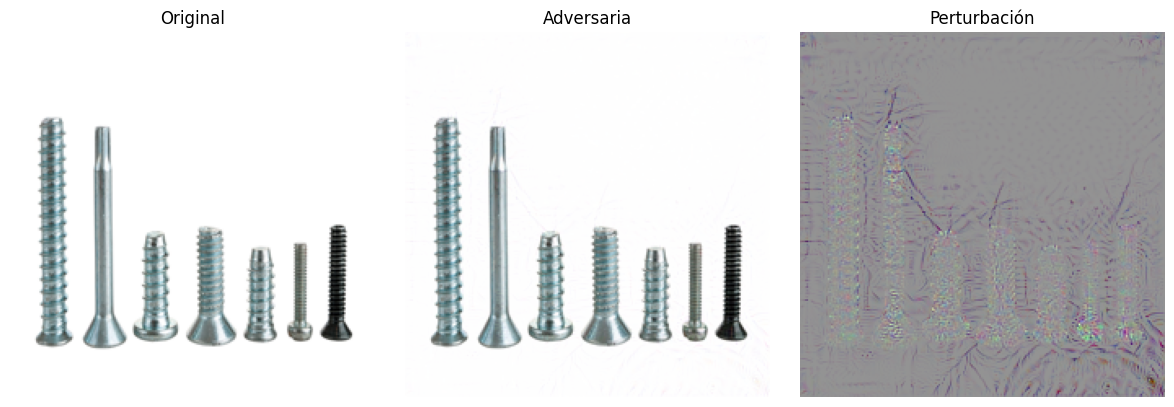

In [32]:
original_np = image[0].detach().cpu().permute(1, 2, 0).numpy()
adversarial_np = attack_image[0].detach().cpu().permute(1, 2, 0).numpy()
perturbation = adversarial_np - original_np

perturbation_vis = perturbation - perturbation.min()
perturbation_vis = perturbation_vis / max(perturbation_vis.max(), 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(original_np)
axes[0].set_title("Original")
axes[1].imshow(adversarial_np)
axes[1].set_title("Adversaria")
axes[2].imshow(perturbation_vis)
axes[2].set_title("Perturbación")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

Si el ataque funciona, la probabilidad de la clase objetivo debería subir mientras la pérdida baja.

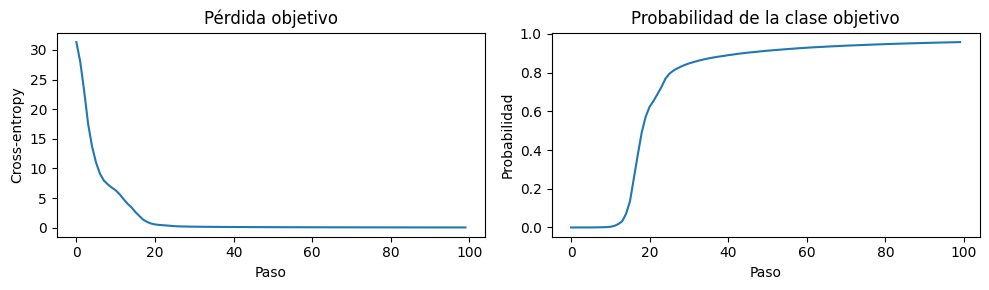

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(loss_history)
axes[0].set_title("Pérdida objetivo")
axes[0].set_xlabel("Paso")
axes[0].set_ylabel("Cross-entropy")

axes[1].plot(target_prob_history)
axes[1].set_title("Probabilidad de la clase objetivo")
axes[1].set_xlabel("Paso")
axes[1].set_ylabel("Probabilidad")

plt.tight_layout()
plt.show()